In [2]:
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, cross_val_predict, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.losses import CategoricalCrossentropy

import pandas as pd
import numpy as np
from matplotlib  import pyplot as plt
import seaborn as sns

2025-05-24 16:41:32.873859: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
#from car_price_prossessing_functions import *
from data_preprocessing import *

In [4]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Input, Dense


In [5]:
model_yaml_path = "/Users/colin/Library/CloudStorage/OneDrive-UniversitedeMontreal/On_Going_Studies/IVADO_Project/AI_Workshop/config/data_config.yaml"
cars_file_path = '/Users/colin/Library/CloudStorage/OneDrive-UniversitedeMontreal/On_Going_Studies/IVADO_Project/car_prices.csv'
population_file_path = '/Users/colin/Library/CloudStorage/OneDrive-UniversitedeMontreal/On_Going_Studies/IVADO_Project/states_populations_yr2015.csv'

---
---
# Imputation des valeurs manquantes avec la méthode MICE dans R

Nous allons effectuer une **imputation des valeurs manquantes** dans notre base de données à l’aide de la méthode **MICE (Multivariate Imputation by Chained Equations)**, disponible dans le logiciel **R**. Cette approche consiste à estimer des modèles de prédiction pour chaque variable contenant des données manquantes.

#### 🌱 Hypothèse de base

La méthode MICE repose sur l’hypothèse que les données sont **manquantes de façon aléatoire** (*Missing At Random*, MAR). Cela signifie que la probabilité qu’une valeur soit manquante peut dépendre des autres variables observées, mais **pas** de la valeur manquante elle-même.

#### 🔁 Principe de la méthode (exemple simplifié)

Imaginons une base avec trois variables : **A**, **B** et **C**, où seule **C** est entièrement observée.

1. **Étape initiale (itération 0)**  
   On commence par remplir les valeurs manquantes de **A** et **B** avec une valeur simple comme la moyenne, la médiane ou la valeur la plus fréquente.

2. **Étapes suivantes (itérations 1 à _maxit_)** :
   - Ajuster un modèle pour prédire **A** à partir de **B** et **C**, en utilisant les valeurs mises à jour de **B**. Utiliser ce modèle pour imputer les valeurs manquantes de **A**.
   - Ajuster ensuite un modèle pour prédire **B** à partir de **A** et **C**, en utilisant les valeurs mises à jour de **A**. Utiliser ce modèle pour imputer les valeurs manquantes de **B**.
   - Répéter ce processus plusieurs fois pour stabiliser les estimations.

Ce processus s’appelle une **imputation par équations chaînées**.

#### 📦 Imputation multiple

Pour tenir compte de l’incertitude liée aux valeurs manquantes, MICE génère plusieurs versions imputées de la base de données. Chaque version correspond à une "réalisation plausible" des données complètes.  
Dans notre cas, nous allons conserver **une seule base imputée**.

#### ⚙️ Méthodes d’imputation par défaut dans MICE

Par défaut, MICE utilise différents modèles selon le type de variable :

- **PMM** (*predictive mean matching - pmm*) pour les variables numériques
- **Régression logistique** (*logistic regression - logreg*) pour les variables binaires
- **Régression polytomique** (*polytomous regression - polyreg*) pour les variables qualitatives non ordonnées
- **Modèle à rapports proportionnels** (*proportional odds - polr*) pour les variables qualitatives ordonnées

#### 🤖 Utilisation d’une méthode de machine learning

Dans notre cas, **nous n’allons pas utiliser ces méthodes par défaut**. À la place, nous allons utiliser une approche basée sur **le machine learning** — par exemple, une **forêt aléatoire** (*random forest*) ou un **réseau de neurones profond** (*deep neural network*) — pour améliorer la qualité des imputations.


---
### Importation des données

S'assurer que l'argument $DropNa$ de la fonction $subset\_var\_of\_interest$ prenne la valeur $False$

In [6]:
config = load_config(model_yaml_path)

df = load_data(cars_file_path); pop_df = load_data(population_file_path) #.drop('population (2015)', axis=1)

df = process_dates(df)

df = define_market(
    df, market_vars=config['var_of_interest']['marketvar'], 
    market_label='market', market_code='marketid', minsize=20, DropSmallMarkets=True
)

df =  preprocess_color_interior(df)

df = subset_var_of_interest(
    df, 
    var_of_interest=config['var_of_interest']['numerical']+['state']+config['var_of_interest']['unordered'], 
    marketvar='marketid', productvar=config['var_of_interest']['productvar'][0], 
    DropNa=False
)
df = change_to_numerical(df, config['var_of_interest']['numerical'])

df = order_unorder_categorical_var(
    df, ordered=config['var_of_interest']['ordered'], unordered=config['var_of_interest']['unordered'], 
    ordered_masks=config['ordered_masks'], unordered_masks=config['unordered_masks'], 
    ordered_min_frequencies=config['ordered_min_frequencies'], 
    unordered_min_frequencies=config['unordered_min_frequencies']
)


38 rows with invalid dates have been dropped

63 markets with sizes lower than 20 have been dropped making 485 dropped rows 


Number of missing per relevant variable in the remaining dataframe 
 marketid            0
make            10282
sellingprice        0
odometer           93
condition       11794
state               0
year                0
body            13174
color           25416
interior        17808
dtype: int64


In [7]:
# Add row ids (saleid) and Remove marketid from df
if 'saleid' not in df.columns:
        df['saleid'] = df.index
df_to_impute = df.drop('marketid',axis=1)

In [8]:
# Check missing values
np.sum(df_to_impute.isna(), axis=0)

make            10282
sellingprice        0
odometer           93
condition       11794
state               0
year                0
body            13174
color           25416
interior        17808
saleid              0
dtype: int64

In [9]:
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri


def mice_impute_from_R(data, numerical=[], ordered=[], unordered=[], 
                       numerical_ordered_unordered_methods=['pmm','plor','polyreg'], nb_cores=1):

    """
    Run linear model with Lasso and cross validation using cv.glmnet from R

    numerical_ordered_unodered_lists : a list of lists of strings (column names per data type). 
    """
    
    df = data.copy()
    
    R_script = \
    \
    """
    
    library(mice)
    library(dplyr)
    library(doParallel)
    
    set.seed(10101)

    if (('saleid' %in% colnames(df))==FALSE){
      df$saleid <- seq(nrow(df))
    }

    # Set the types in data for ordered and unordered categorical columns

    if (length(ordered) > 0) {
      for (var in ordered) {
        df[,var] <- factor(df[,var], ordered = TRUE)
      }
    }
    
    if (length(unordered) > 0) {
      for (var in unordered) {
        df[,var] <- factor(df[,var], ordered = FALSE)
      }
    }

    # set the blocks and method parameters for the mice (exclude data types with no variables)
     
    blocks <- list()
    methods <- NULL
    if (length(numerical)!=0){
       methods <- c(methods, numerical_ordered_unordered_methods[1])
       blocks$numerical <- numerical
    }
    if (length(ordered)!=0){
       methods <- c(methods, numerical_ordered_unordered_methods[2])
       blocks$ordered <- ordered
    }
    if (length(unordered)!=0){
       methods <- c(methods, numerical_ordered_unordered_methods[3])
       blocks$unordered <- unordered
    }
    
    # If the dataset is too heavy, focus on incomlete rows, with eventually few additional rows
    
    incompleteness_filter <- !complete.cases(df)
    complete_df <- df[!incompleteness_filter,]
    nb_incomplete_rows <- sum(incompleteness_filter)
    if ((nb_incomplete_rows<=100000) & (nrow(df)>100000)){
      sampled_rows <- sample_n(complete_df, 100000-nb_incomplete_rows)
      sampled_rows_filter <- df$saleid %in% sampled_rows$saleid
      final_filter <- incompleteness_filter | sampled_rows_filter
    } else {
      final_filter <- incompleteness_filter
    }

    # Fit the MICE imputer
    
    imputer <- futuremice(
      data=select(df[final_filter,], -saleid),
      blocks=blocks, 
      method=methods,
      m=1, maxit=10,
      parallelseed = 10101, print = FALSE, n.core = nb_cores
    )
    
    imputed_df <- complete(imputer)
    
    imputed_df <- cbind(df[final_filter,'saleid'], imputed_df)
    colnames(imputed_df)[1] <- 'saleid'
    imputed_df <- rbind(imputed_df, df[!final_filter,])

    # Convert all factor columns back to character
    imputed_df <- imputed_df %>%
    mutate(across(where(is.factor), as.character))
    
    """
    
    pandas2ri.activate()
    robjects.globalenv['df'] = pandas2ri.py2rpy(data)
    robjects.globalenv['nb_cores'] = robjects.IntVector([nb_cores])[0]
    robjects.globalenv['numerical'] = robjects.StrVector(numerical)
    robjects.globalenv['ordered'] = robjects.StrVector(ordered)
    robjects.globalenv['unordered'] = robjects.StrVector(unordered)
    robjects.globalenv['numerical_ordered_unordered_methods'] = robjects.StrVector(numerical_ordered_unordered_methods)

    robjects.r(R_script)
    imputed_df = robjects.conversion.rpy2py(robjects.globalenv['imputed_df'])
    
    return imputed_df

In [11]:
def plot_categorical_observed_vs_imputed(df, imputed_df, categorical, nb_subplots_rows=2, nb_subplots_cols=2):
    
    fig = plt.figure(figsize=(nb_subplots_cols*6, nb_subplots_rows*6))
    
    for i in range(len(categorical)):
        
        var = categorical[i]
        incompleteness_filter = df[var].isna()
        incompleteness_IDs = df[incompleteness_filter]['saleid']
        observed_and_imputed_values = imputed_df[var]
        observed_values = df[var][~incompleteness_filter]
        imputed_values = imputed_df[var][imputed_df['saleid'].isin(incompleteness_IDs)]
        
        # Ensure same category order
        categories = sorted(set(observed_values.unique()) | set(imputed_values.unique()) | set(observed_and_imputed_values.unique()))
        
        # Compute value frequencies, reindexed to have same order
        freq_observed_and_imputed = observed_and_imputed_values.value_counts().reindex(categories, fill_value=0)/len(observed_and_imputed_values)
        freq_observed = observed_values.value_counts().reindex(categories, fill_value=0)/len(observed_values)
        freq_imputed = imputed_values.value_counts().reindex(categories, fill_value=0)/len(imputed_values)
        
        # Plot side-by-side bars
        x = range(len(categories))
        width = 0.35
        
        ax=plt.subplot(2,2,i+1)
        plt.bar([j - 2*width/3 for j in x], freq_observed_and_imputed, width=width, color='green', label='Both observed and imputed values')
        plt.bar([j - width/3 for j in x], freq_observed, width=width, color='blue', alpha=0.6, label='Observed values')
        plt.bar([j + width/3 for j in x], freq_imputed, width=width, color='orange', alpha=0.3, label='Imputed missing values')
        plt.xticks(ticks=x, labels=categories)
        plt.xlabel("Category")
        plt.ylabel("Frequency")
        plt.title(var)
        plt.legend()
        plt.tight_layout()
        plt.xticks(rotation=45)
    
    plt.show()    

In [15]:
def plot_numerical_observed_vs_imputed(df, imputed_df, numerical, nb_subplots_rows=1, nb_subplots_cols=2):
    
    fig = plt.figure(figsize=(nb_subplots_cols*6, nb_subplots_rows*6))

    for i in range(len(numerical)):
        var = numerical[i]
        
        incompleteness_filter = df[var].isna()
        incompleteness_IDs = df[incompleteness_filter]['saleid']
        observed_and_imputed_values = imputed_df[var]
        observed_values = df[var][~incompleteness_filter]
        imputed_values = imputed_df[var][imputed_df['saleid'].isin(incompleteness_IDs)]
    
        ax=plt.subplot(1,2,i+1)
        sns.histplot(observed_and_imputed_values, color='green', label='Both observed and imputed values', kde=True, stat='density', bins=30)
        sns.histplot(observed_values, color='blue', label='Observed values', kde=True, stat='density', bins=50, alpha=0.6)
        sns.histplot(imputed_values, color='orange', label='Imputed missing values', kde=True, stat='density', bins=50, alpha=0.3)
        plt.xticks(rotation=45)
        plt.title(var)
        plt.legend()
        plt.xlabel("Value")
        plt.ylabel("Density")
    plt.show()

---
### Imputation par MICE en utilisant les méthodes par défaut


In [17]:
imputed_df = mice_impute_from_R(
    df_to_impute,
    numerical=config['var_of_interest']['numerical'], 
    ordered=config['var_of_interest']['ordered'], 
    unordered=['state']+config['var_of_interest']['unordered'], 
    numerical_ordered_unordered_methods=['pmm','polr','polyreg'], nb_cores=5
)

R[write to console]: 
Attaching package: ‘mice’


R[write to console]: The following object is masked from ‘package:stats’:

    filter


R[write to console]: The following objects are masked from ‘package:base’:

    cbind, rbind


R[write to console]: 
Attaching package: ‘dplyr’


R[write to console]: The following objects are masked from ‘package:stats’:

    filter, lag


R[write to console]: The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


R[write to console]: Loading required package: foreach

R[write to console]: Loading required package: iterators

R[write to console]: Loading required package: parallel

R[write to console]: 
Attaching package: ‘purrr’


R[write to console]: The following objects are masked from ‘package:foreach’:

    accumulate, when


R[write to console]: In addition: 
R[write to console]: Warning message:

R[write to console]: In check.cores(n.core, available, m) :
R[write to console]: 
 
R[write to console]: 

In [18]:
# Check missing values
np.sum(imputed_df.isna(), axis=0)

saleid          0
make            0
sellingprice    0
odometer        0
condition       0
state           0
year            0
body            0
color           0
interior        0
dtype: int64

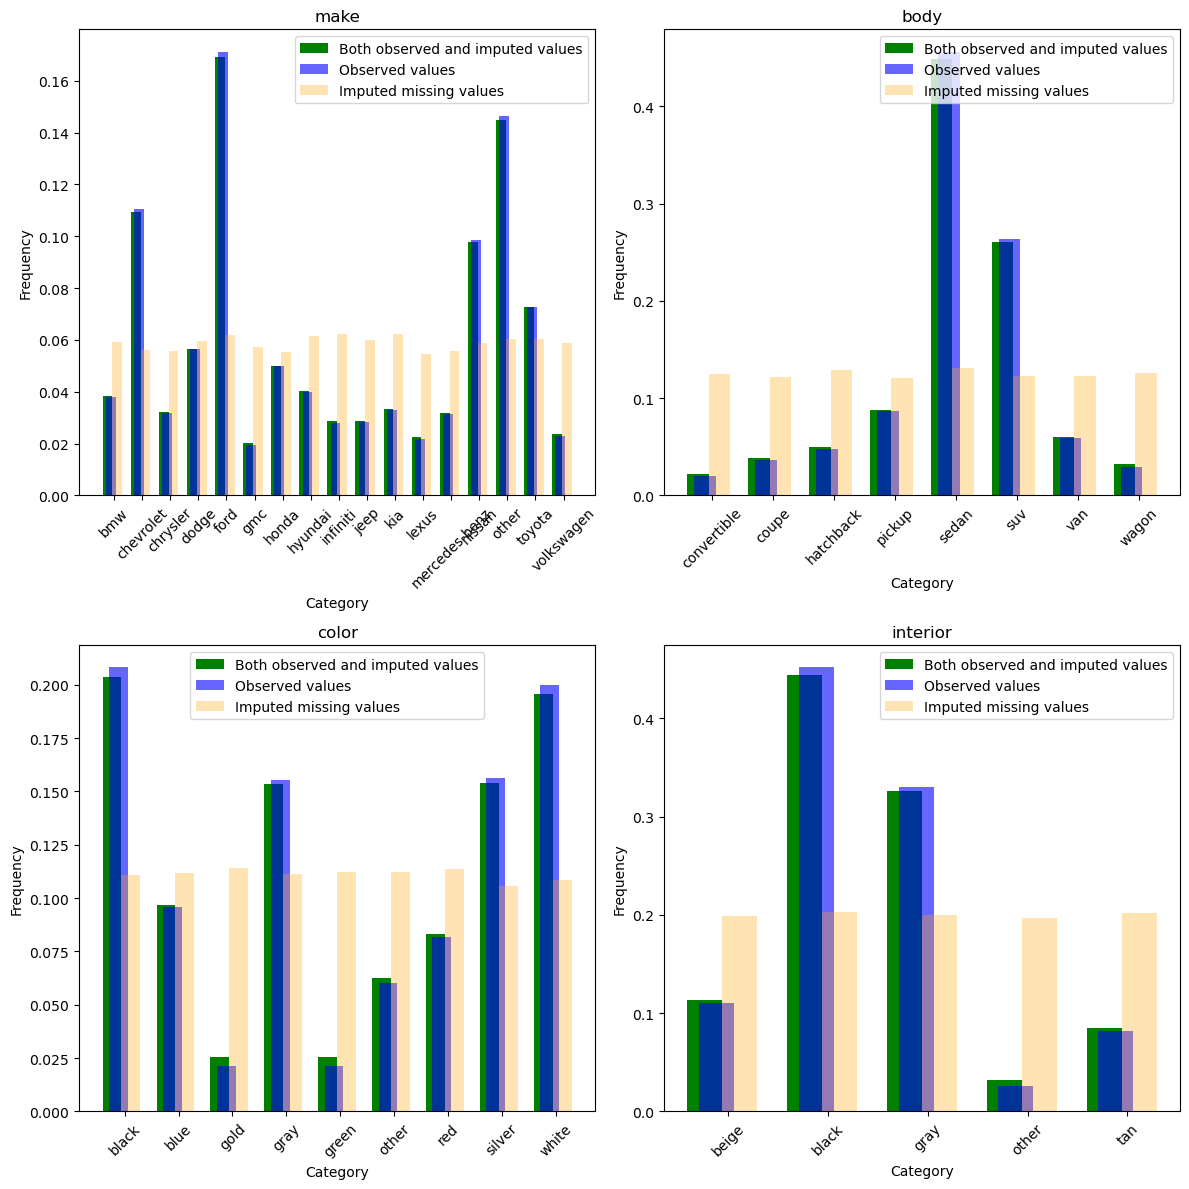

In [19]:

plot_categorical_observed_vs_imputed(
    df_to_impute, imputed_df, categorical=['make','body','color','interior'], nb_subplots_rows=2, nb_subplots_cols=2
)


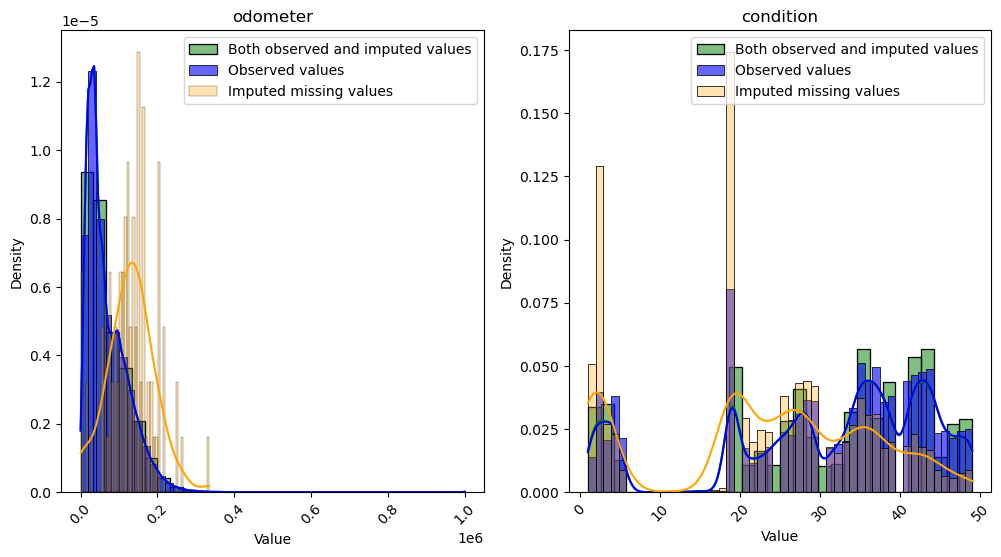

In [20]:
plot_numerical_observed_vs_imputed(
    df_to_impute, imputed_df, numerical=['odometer','condition'], nb_subplots_rows=1, nb_subplots_cols=2
)

---
### Imputation par MICE en utilisant les méthodes des forêts aléatoires


In [22]:
imputed_df = mice_impute_from_R(
    df_to_impute,
    numerical=config['var_of_interest']['numerical'], 
    ordered=config['var_of_interest']['ordered'], 
    unordered=['state']+config['var_of_interest']['unordered'], 
    numerical_ordered_unordered_methods=['rf','rf','rf'], nb_cores=5
)

# If we want to customize the random forest parameters inside the MICE procedure, and if we want to get the prediction performances, 
# we can define:
"""
mice.impute.rf_custom <- function(y, ry, x, wy = NULL, ...) {
  require(randomForest)
  rf <- randomForest(x[ry, ], y[ry], ntree = 500, mtry = 4)  # ← your custom settings
  preds <- predict(rf, newdata = x[!ry, ])

  # Evaluate performance (on training set or via OOB)
  y_train <- y[ry]
  y_pred_train <- predict(rf, newdata = x[ry, ])
  mse <- mean((y_pred_train - y_train)^2)
  cat("RF training MSE:", round(mse, 3), "\n")

  return(preds)
}

then set method = "rf_custom" for the columns to be imputed using random forests.
"""

R[write to console]: In addition: 
R[write to console]: Warning message:

R[write to console]: In check.cores(n.core, available, m) :
R[write to console]: 
 
R[write to console]:  'n.core' exceeds the maximum number of available cores on your machine or the number of imputations, and is set to 1



'\nmice.impute.rf_custom <- function(y, ry, x, wy = NULL, ...) {\n  require(randomForest)\n  rf <- randomForest(x[ry, ], y[ry], ntree = 500, mtry = 4)  # ← your custom settings\n  preds <- predict(rf, newdata = x[!ry, ])\n\n  # Evaluate performance (on training set or via OOB)\n  y_train <- y[ry]\n  y_pred_train <- predict(rf, newdata = x[ry, ])\n  mse <- mean((y_pred_train - y_train)^2)\n  cat("RF training MSE:", round(mse, 3), "\n")\n\n  return(preds)\n}\n\nthen set method = "rf_custom" for the columns to be imputed using random forests.\n'

In [23]:
# Check missing values
np.sum(imputed_df.isna(), axis=0)

saleid          0
make            0
sellingprice    0
odometer        0
condition       0
state           0
year            0
body            0
color           0
interior        0
dtype: int64

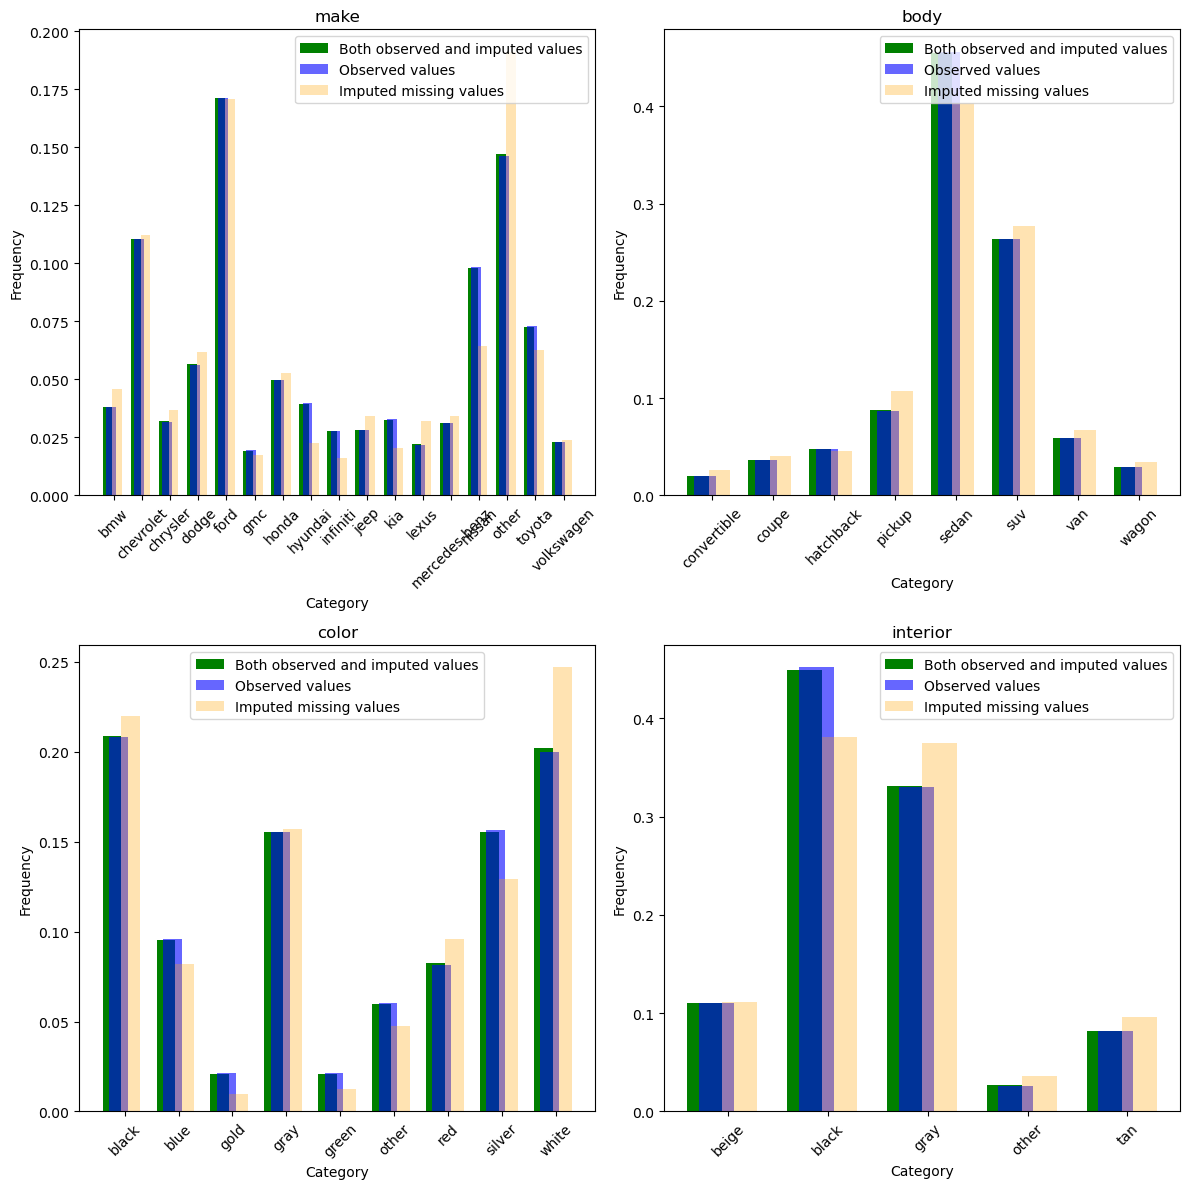

In [24]:
plot_categorical_observed_vs_imputed(
    df_to_impute, imputed_df, categorical=['make','body','color','interior'], nb_subplots_rows=2, nb_subplots_cols=2
)

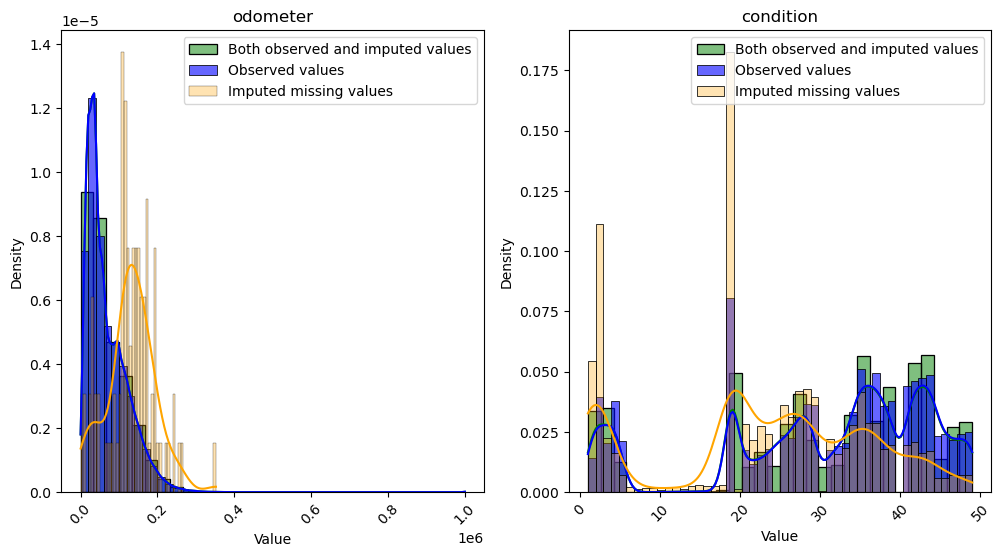

In [25]:
plot_numerical_observed_vs_imputed(
    df_to_impute, imputed_df, numerical=['odometer','condition'], nb_subplots_rows=1, nb_subplots_cols=2
)

---
---
# Detection et remplacement des valeurs aberrantes par AutoEncodeur (une application du deep learning)

Dans l’analyse de données économiques ou financières, la présence de valeurs aberrantes (outliers) peut biaiser les résultats économétriques, fausser les estimateurs et réduire la robustesse des modèles.

Les AutoEncodeurs, issus du deep learning, offrent une méthode innovante pour identifier automatiquement ces anomalies. Il s’agit de réseaux de neurones entraînés à reconstruire les données “normales” en apprenant leur structure latente. Lorsqu’une observation ne peut pas être bien reconstruite (c’est-à-dire que l’erreur de reconstruction est élevée), cela signale une valeur atypique.

Cette méthode permet non seulement de détecter les outliers, mais aussi de les remplacer par des valeurs reconstruites par le modèle, souvent plus cohérentes avec la structure globale des données. Cela améliore la qualité des jeux de données utilisés dans les analyses économétriques et les modèles prédictifs.

In [ ]:
#Set the df used to check for anomalies
df_for_anomalies = imputed_df.drop('saleid',axis=1)
#Standardize numerical columns
df_numeric_mean = df_for_anomalies[['sellingprice','odometer','condition']].mean(axis=0)
df_numeric_std = df_for_anomalies[['sellingprice','odometer','condition']].std(axis=0)
df_for_anomalies[['sellingprice','odometer','condition']] = (df_for_anomalies[['sellingprice','odometer','condition']]-df_numeric_mean)/df_numeric_std
# Split the data
X_numeric = df_for_anomalies[['sellingprice','odometer','condition']]
X_state = pd.get_dummies(df_for_anomalies[['state']]); X_year = pd.get_dummies(df_for_anomalies[['year']])
X_make = pd.get_dummies(df_for_anomalies[['make']]); X_body = pd.get_dummies(df_for_anomalies[['body']])
X_color = pd.get_dummies(df_for_anomalies[['color']]); X_interior = pd.get_dummies(df_for_anomalies[['interior']])
df_for_anomalies_train, df_for_anomalies_test, X_numeric_train,  X_numeric_test, X_state_train, X_state_test, X_year_train, X_year_test,  X_make_train, X_make_test, X_body_train, X_body_test, X_color_train, X_color_test, X_interior_train, X_interior_test = train_test_split(
    df_for_anomalies, X_numeric, X_state, X_year, X_make, X_body, X_color, X_interior, test_size=0.1, random_state=42
)

X_list_train = [X_numeric_train, X_state_train, X_year_train, X_make_train, X_body_train, X_color_train, X_interior_train]
X_list_test = [X_numeric_test, X_state_test, X_year_test, X_make_test, X_body_test, X_color_test, X_interior_test]

X_train = pd.concat(X_list_train, axis=1)
X_test = pd.concat(X_list_test, axis=1)

#X_train, X_test = train_test_split(X, test_size=0.1, random_state=42)
#X.head()

X_train.shape, X_test.shape

In [ ]:
X_numeric_train.shape,  X_numeric_test.shape, X_state_train.shape, X_state_test.shape

In [ ]:
#count levels for the categorical columns
for var in ['state','year','make','body','color','interior']:
    print(f"Column {var} has {len(imputed_df[var].unique())} levels")

In [ ]:
# Input
input_dim = X_train.shape[1]
input_layer = Input(shape=(input_dim,))

# Encoder
encoded = Dense(50, activation='relu')(input_layer)
encoded = Dense(20, activation='relu')(encoded)
encoded = Dense(10, activation='relu')(encoded)

# Decoder for numerical columns (e.g., 3 continuous values)
numerical_output = Dense(X_numeric_train.shape[1], activation='linear', name='numerical_output')(encoded)

# Decoder for categorical columns ('state','year','make','body','color','interior'), each with nb of dummies (38, 17, 17, 8, 9, 5)
categorical_output_state = Dense(X_state_train.shape[1], activation='softmax', name='categorical_output_state')(encoded)
categorical_output_year = Dense(X_year_train.shape[1], activation='softmax', name='categorical_output_year')(encoded)
categorical_output_make = Dense(X_make_train.shape[1], activation='softmax', name='categorical_output_make')(encoded)
categorical_output_body = Dense(X_body_train.shape[1], activation='softmax', name='categorical_output_body')(encoded)
categorical_output_color = Dense(X_color_train.shape[1], activation='softmax', name='categorical_output_color')(encoded)
categorical_output_interior = Dense(X_interior_train.shape[1], activation='softmax', name='categorical_output_interior')(encoded)

# Model with multiple outputs
autoencoder = Model(
    inputs=input_layer, 
    outputs=[numerical_output, categorical_output_state, categorical_output_year, categorical_output_make, 
             categorical_output_body, categorical_output_color, categorical_output_interior]
)

# Compile with multiple loss functions
autoencoder.compile(optimizer='adam',
                    loss={
                        'numerical_output': 'mae',
                        'categorical_output_state': 'categorical_crossentropy',
                        'categorical_output_year': 'categorical_crossentropy',
                        'categorical_output_make': 'categorical_crossentropy',
                        'categorical_output_body': 'categorical_crossentropy',
                        'categorical_output_color': 'categorical_crossentropy',
                        'categorical_output_interior': 'categorical_crossentropy',
                    },
                    loss_weights={
                        'numerical_output': 1.0,
                        'categorical_output_state': 1.0,
                        'categorical_output_year': 1.0,
                        'categorical_output_make': 1.0,
                        'categorical_output_body': 1.0,
                        'categorical_output_color': 1.0,
                        'categorical_output_interior': 1.0
                    })

autoencoder.summary()

# Fit the model
history = autoencoder.fit(
    X_train, [X_numeric_train, X_state_train, X_year_train, X_make_train, X_body_train, X_color_train, X_interior_train], 
    epochs=100, batch_size=1000, validation_split=0.2, verbose=False
)



In [ ]:
X_list_train_predict =  autoencoder.predict(X_train)
X_numeric_train_predict, X_state_train_predict, X_year_train_predict, X_make_train_predict, X_body_train_predict, \
X_color_train_predict, X_interior_train_predict = X_list_train_predict

X_list_test_predict =  autoencoder.predict(X_test)
X_numeric_test_predict, X_state_test_predict, X_year_test_predict, X_make_test_predict, X_body_test_predict, \
X_color_test_predict, X_interior_test_predict = X_list_test_predict

In [ ]:
## Reconstruct the input datasets
def reconstruct_columns(y_true, y_pred, numerical=True):
    #y_true should be a dataframe
    if numerical:
        result = pd.DataFrame(y_pred, columns=y_true.columns, index=y_true.index)
    else:
        result = pd.DataFrame(y_pred, columns=y_true.columns, index=y_true.index)
        colname = str(result.columns[0]).rpartition('_')[0]
        result = result.idxmax(axis=1).astype('string').str.rsplit('_', n=1).str[-1]
        result = pd.Series(result, name=colname)
    return result


In [ ]:
df_for_anomalies_test_denoised = reconstruct_columns(y_true=X_list_test[0], y_pred=X_list_test_predict[0], numerical=True)
for i in range(1,len(X_list_train)):
    D = reconstruct_columns(y_true=X_list_test[i], y_pred=X_list_test_predict[i], numerical=False)
    df_for_anomalies_test_denoised = pd.concat([df_for_anomalies_test_denoised, D], axis=1)

    

In [ ]:
def get_errors(y_true_list, y_pred_list, weight_list=[]):
    cce = CategoricalCrossentropy(reduction=tf.keras.losses.Reduction.NONE)
    if len(weight_list)==0:
        weight_list_1 = [1 for i in range(len(y_true_list))]
    else:
        weight_list_1 = weight_list
    result = weight_list_1[0]*np.mean(np.abs(y_true_list[0] - y_pred_list[0]), axis=1)
    for i in range(1,len(y_true_list)):
        result = result + weight_list_1[i]*cce(y_true_list[i],y_pred_list[i]).numpy()
    return pd.Series(result, index=y_true_list[0].index)

In [ ]:
errors_train = get_errors(
    y_true_list = X_list_train, y_pred_list = X_list_train_predict, weight_list=[1., 1., 1., 1., 1., 1., 1.]
)
errors_test = get_errors(
    y_true_list = X_list_test, y_pred_list = X_list_test_predict, weight_list=[1., 1., 1., 1., 1., 1., 1.]
)

In [ ]:
pd.Series(errors_train).describe(percentiles=np.arange(200)/200)

In [ ]:
# True data detected as anomalies
d = df_for_anomalies_test[errors_test >= 3][df_for_anomalies_test_denoised.columns]
d[['sellingprice','odometer','condition']] = (d[['sellingprice','odometer','condition']]*df_numeric_std)+df_numeric_mean
d

In [ ]:
# Denoised anomalies
d = df_for_anomalies_test_denoised[errors_test >= 3]#[d.columns]
d[['sellingprice','odometer','condition']] =np.round( ((d[['sellingprice','odometer','condition']]*df_numeric_std)+df_numeric_mean), 2)
d

In [ ]:
#Distribution of the observed values vs imputed values

fig = plt.figure(figsize=(15, 7))

vars = ['sellingprice','odometer','condition']

i = 0
for i in range(len(vars)):
    var = vars[i]
    ax=plt.subplot(1,3,i+1)
    sns.histplot(df_for_anomalies_test[var], color='blue', label='True values', kde=True, stat='density', bins=50, alpha=1.)
    sns.histplot(df_for_anomalies_test_denoised[var], color='orange', label='Denoised values', kde=True, stat='density', bins=50, alpha=0.6)
    plt.xticks(rotation=45)
    plt.title(var)
    plt.legend()
    plt.xlabel("Value")
    plt.ylabel("Density")
plt.show()

In [ ]:
#Distribution of the observed values vs imputed values

fig = plt.figure(figsize=(15, 15))

vars = [['state','year'],['make','body'],['color','interior']]

i = 0
for i1 in range(2):
    for i2 in range(2):
        var = vars[i1][i2]
        true_values = df_for_anomalies_test[var]
        denoised_values = df_for_anomalies_test_denoised[var]
        # Ensure same category order
        categories = sorted(set(true_values.unique()) | set(denoised_values.unique()))
        # Compute value frequencies, reindexed to have same order
        freq_true = true_values.value_counts().reindex(categories, fill_value=0)/len(true_values)
        freq_denoised = denoised_values.value_counts().reindex(categories, fill_value=0)/len(denoised_values)
        # Plot side-by-side bars
        x = range(len(categories))
        width = 0.35
        i = i+1
        ax=plt.subplot(2,2,i)
        plt.bar([j - width/2 for j in x], freq_true, width=width, color='blue', alpha=1., label='True values')
        plt.bar([j + width/2 for j in x], freq_denoised, width=width, color='orange', alpha=0.6, label='Denoised values')
        plt.xticks(ticks=x, labels=categories)
        plt.xlabel("Category")
        plt.ylabel("Frequency")
        plt.title(var)
        plt.legend()
        plt.tight_layout()
        plt.xticks(rotation=45)

plt.show()